In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 

## Part A: Vector & Matrix Fundamentals

In [3]:


# 1.Represent each student’s subject scores as a vector.
student_scores = np.array([85, 90, 78, 92, 88])
print("Student Scores Vector:", student_scores)


Student Scores Vector: [85 90 78 92 88]


In [4]:
# 2.Norm-1 and Norm-2 of vectors
print("Norm-1:", np.linalg.norm(student_scores, ord=1))  # Norm-1
print("Norm-2:", np.linalg.norm(student_scores, ord=2))  # Norm-2

Norm-1: 433.0
Norm-2: 193.9510247459394


In [5]:
# 3.Dot product and angle between two students score vectors.
student_scores_2 = np.array([80, 85, 82, 88, 84])

# find the dot product 
dot_product = np.dot(student_scores, student_scores_2)

# find magnitudes of the vectors
norm_a = np.linalg.norm(student_scores)
norm_b = np.linalg.norm(student_scores_2)

# calculate the cosine of the angle between the two vectors
cosine_angle = dot_product / (norm_a * norm_b)

print("Dot Product:", dot_product)
print("Cosine Angle:", cosine_angle)

Dot Product: 36334
Cosine Angle: 0.999228117957704


In [6]:
# Find the projection of one vector onto another.
projection = (np.dot(student_scores, student_scores_2) / np.linalg.norm(student_scores_2)**2) * student_scores_2
print("Projection:", projection)

Projection: [82.69708953 87.86565763 84.76451677 90.96679849 86.83194401]


## Part B: Matrix Operations

In [7]:
# matrix of students × subjects

student_subjects = np.array([
    [85, 90, 78, 92, 88],
    [80, 85, 82, 88, 84]
])
print("Student-Subjects Matrix:\n", student_subjects)


Student-Subjects Matrix:
 [[85 90 78 92 88]
 [80 85 82 88 84]]


In [8]:
# Matrix addition and multiplication.
student_subjects_1 = np.array([
    [85, 90, 78, 92, 88],
    [80, 85, 82, 88, 84]
])

student_subjects_2 = np.array([
    [75, 80, 70, 85, 78]
])

matrix_addition = student_subjects_1 + student_subjects_2

matrix_multiplication = np.dot(student_subjects_1, student_subjects_2.T)

print("Matrix Addition:\n", matrix_addition)

print("Matrix Multiplication:\n", matrix_multiplication)


Matrix Addition:
 [[160 170 148 177 166]
 [155 165 152 173 162]]
Matrix Multiplication:
 [[33719]
 [32572]]


In [9]:
# matrix transpose and inverse.
print("Transpose of Student-Subjects Matrix:\n", student_subjects_1.T)

# Note: The inverse of a non-square matrix does not exist. For demonstration, let's create a square matrix.
square_matrix = np.array([
    [1, 2],
    [3, 4]
])
print("Square Matrix:\n", square_matrix)
print("Inverse of Square Matrix:\n", np.linalg.inv(square_matrix))


Transpose of Student-Subjects Matrix:
 [[85 80]
 [90 85]
 [78 82]
 [92 88]
 [88 84]]
Square Matrix:
 [[1 2]
 [3 4]]
Inverse of Square Matrix:
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [10]:
# Determinant.
print("Determinant of Square Matrix:", np.linalg.det(square_matrix))

Determinant of Square Matrix: -2.0000000000000004


## Part C: Linear Transformations & Geometry


## Line, Plane, and Hyperplane with Respect to Dataset Dimensions

### Dataset

In this project, the dataset consists of **students' scores in five subjects**.

Example:

| Student | Math | Science | English | Physics | Computer |
|---------|------|----------|----------|----------|----------|
| S1 | 85 | 90 | 78 | 92 | 88 |
| S2 | 80 | 85 | 82 | 88 | 84 |
| S3 | 75 | 80 | 70 | 85 | 78 |
| S4 | 90 | 95 | 88 | 94 | 92 |

Each subject represents one **feature (dimension)**.

Therefore,

- Number of Features = **5**
- Dataset Dimension = **5D**

---

### 1. Line (1 Dimension)

A **line** is a one-dimensional (1D) geometric object that has only one direction.

If the dataset contained only **one feature**, such as **Math Score**, each student would lie on a line.

#### Example

| Student | Math |
|---------|------|
| S1 | 85 |
| S2 | 80 |
| S3 | 75 |

This is a **1-dimensional dataset**, so the data points lie on a **line**.

---

### 2. Plane (2 Dimensions)

A **plane** is a two-dimensional (2D) surface defined by two features.

If we select two subjects, for example:

- Math
- Science

each student can be represented as a point:

- S1 = (85, 90)
- S2 = (80, 85)
- S3 = (75, 80)

These points lie on a **2D plane**.

#### Example

| Student | Math | Science |
|---------|------|----------|
| S1 | 85 | 90 |
| S2 | 80 | 85 |
| S3 | 75 | 80 |

Dimension = **2D**

---

### 3. Hyperplane (3 or More Dimensions)

A **hyperplane** is a flat surface in **three or more dimensions** that separates data into different regions or classes.

Since our dataset contains **5 features**, each student is represented as:

$$
(85,\;90,\;78,\;92,\;88)
$$

This is a **5-dimensional point**.

A machine learning algorithm such as **Linear Discriminant Analysis (LDA)** or a **Linear Classifier** can use a **hyperplane** to separate students into classes, such as:

- Above Average
- Below Average

In this project, the hyperplane exists in **5-dimensional feature space**.

---



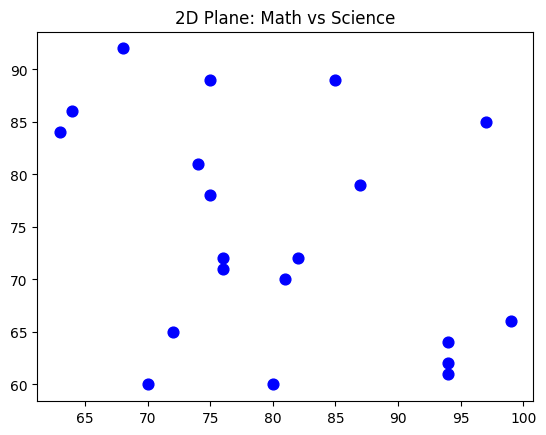

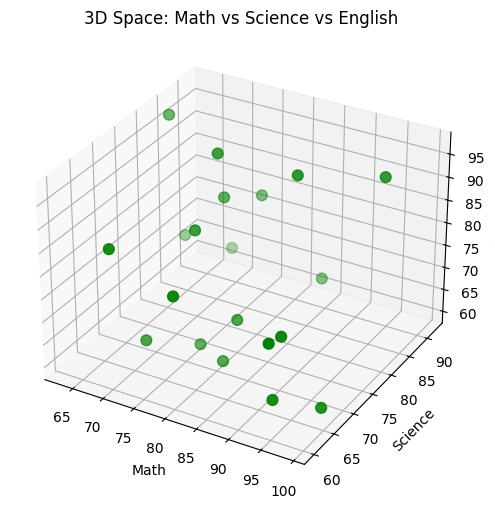

In [11]:
# Show how dimensionality increases from 2D → 3D → higher dimensions with hyperplanes.
import matplotlib.pyplot as plt
math = np.random.randint(60, 100, 20)
science = np.random.randint(60, 100, 20)
english = np.random.randint(60, 100, 20)

fig = plt.figure()
plt.scatter(math, science, color='blue', s=60)
plt.title('2D Plane: Math vs Science')
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(math, science, english, color='green', s=60)
ax.set_xlabel('Math')
ax.set_ylabel('Science')
ax.set_zlabel('English')
plt.title('3D Space: Math vs Science vs English')
plt.show()

## Part D: Eigenvalues & Decomposition


In [12]:
# Compute the eigenvalues and eigenvectors of the covariance matrix.
data=np.array([
    [85, 90, 78, 92, 88],
    [80, 85, 82, 88, 84],
    [75, 80, 70, 85, 78]
])

cov_matrix = np.cov(data, rowvar=False)
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[25.         25.         20.         17.5        25.        ]
 [25.         25.         20.         17.5        25.        ]
 [20.         20.         37.33333333 12.66666667 22.66666667]
 [17.5        17.5        12.66666667 12.33333333 17.33333333]
 [25.         25.         22.66666667 17.33333333 25.33333333]]


In [13]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:\n", eigenvalues)

print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [ 1.08049424e+02 -8.58553209e-15  1.69505763e+01 -2.78090309e-15
 -7.73263475e-16]
Eigenvectors:
 [[-0.46817291 -0.83851786 -0.27875064  0.20140728  0.02882394]
 [-0.46817291  0.35406258 -0.27875064 -0.71668941 -0.3164138 ]
 [-0.47652801 -0.02279024  0.86890393 -0.0879611  -0.12982992]
 [-0.32134668  0.26697132 -0.26336948 -0.09836482 -0.53932129]
 [-0.48092162  0.31580754 -0.14226259  0.65450638  0.76897869]]


In [14]:
# Perform LU Decomposition of the dataset matrix.
from scipy.linalg import lu , svd
p, l, u = lu(data)
print("LU Decomposition:\n")
print("P Matrix:\n", p)
print("L Matrix:\n", l)
print("U Matrix:\n", u)

LU Decomposition:

P Matrix:
 [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
L Matrix:
 [[1.         0.         0.        ]
 [0.88235294 1.         0.        ]
 [0.94117647 0.5        1.        ]]
U Matrix:
 [[85.         90.         78.         92.         88.        ]
 [ 0.          0.58823529  1.17647059  3.82352941  0.35294118]
 [ 0.          0.          8.         -0.5         1.        ]]


In [15]:
# Perform Singular Value Decomposition (SVD) and explain its role in dimensionality reduction.
u, s, vt = svd(data)
print("Singular Values:\n", s)
print("Left Singular Vectors:\n", u)
print("Right Singular Vectors:\n", vt)

Singular Values:
 [320.87346026   5.93387885   2.23865599]
Left Singular Vectors:
 [[-0.60437926  0.41730176 -0.67866409]
 [-0.58408951 -0.81141156  0.02123012]
 [-0.54181652  0.40923162  0.7341419 ]]
Right Singular Vectors:
 [[-0.43236869 -0.4593308  -0.41438167 -0.47700166 -0.45036627]
 [ 0.21067098  0.22341291 -0.89991683  0.29866334  0.08157395]
 [-0.41426444 -0.24293859  0.08710752  0.81889123 -0.30198551]
 [-0.65011122  0.75123173 -0.00468988 -0.11240638 -0.01868414]
 [-0.41763073 -0.34019643 -0.10405678  0.00718198  0.8360452 ]]


### Role of SVD in Dimensionality Reduction
- SVD decomposes the original matrix into U, S, and VT.
- The Singular Values (S) indicate the importance of each dimension.
- By keeping only the largest singular values, less important information and noise are removed.
- This reduces the number of dimensions while preserving most of the original information.

## Part E: Dimensionality Reduction

Original Dataset
           Math  Science  English  Physics  Computer
Student 1    85       90       78       92        88
Student 2    80       85       82       88        84
Student 3    75       80       70       85        78
Student 4    90       95       88       94        92

Dataset After PCA
           Principal Component 1  Principal Component 2
Student 1               0.825768              -0.641146
Student 2              -0.609566               0.709723
Student 3              -3.101855              -0.193729
Student 4               2.885654               0.125151


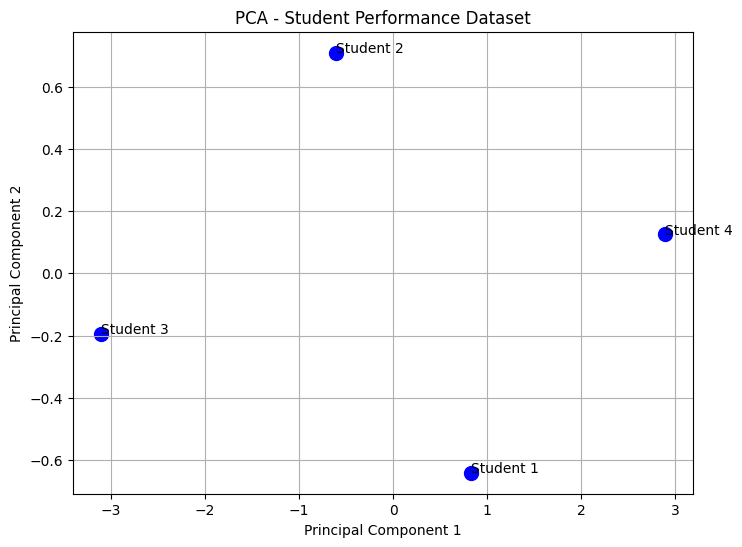

In [16]:
# Apply Principal Component Analysis (PCA) to reduce the dataset from multiple subjects to 2 dimensions.

data = pd.DataFrame({
    "Math":     [85, 80, 75, 90],
    "Science":  [90, 85, 80, 95],
    "English":  [78, 82, 70, 88],
    "Physics":  [92, 88, 85, 94],
    "Computer": [88, 84, 78, 92]
},
index=["Student 1","Student 2","Student 3","Student 4"])

print("Original Dataset")
print(data)

# -------------------------------
# Step 1 : Standardize the Data
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# -------------------------------
# Step 2 : Apply PCA
# -------------------------------

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Convert PCA output into DataFrame
pca_df = pd.DataFrame(
    principal_components,
    columns=["Principal Component 1", "Principal Component 2"],
    index=data.index
)

print("\nDataset After PCA")
print(pca_df)


# -------------------------------
# Visualization
# -------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    color="blue",
    s=100
)

# Display student names
for student, row in pca_df.iterrows():
    plt.text(
        row["Principal Component 1"],
        row["Principal Component 2"],
        student
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Student Performance Dataset")

plt.grid(True)
plt.show()

Original Dataset
   Math  Science  English  Physics  Computer       Category
0    85       90       78       92        88  Above Average
1    80       85       82       88        84  Above Average
2    75       80       70       85        78  Above Average
3    90       95       88       94        92  Above Average
4    60       58       60       62        65  Below Average
5    55       52       55       58        60  Below Average
6    50       48       50       52        55  Below Average
7    45       46       48       50        52  Below Average

Dataset After LDA
         LD1       Category
0 -12.113240  Above Average
1 -12.022956  Above Average
2 -13.717584  Above Average
3 -13.523113  Above Average
4  11.719259  Below Average
5  12.988059  Below Average
6  14.283469  Below Average
7  12.386104  Below Average


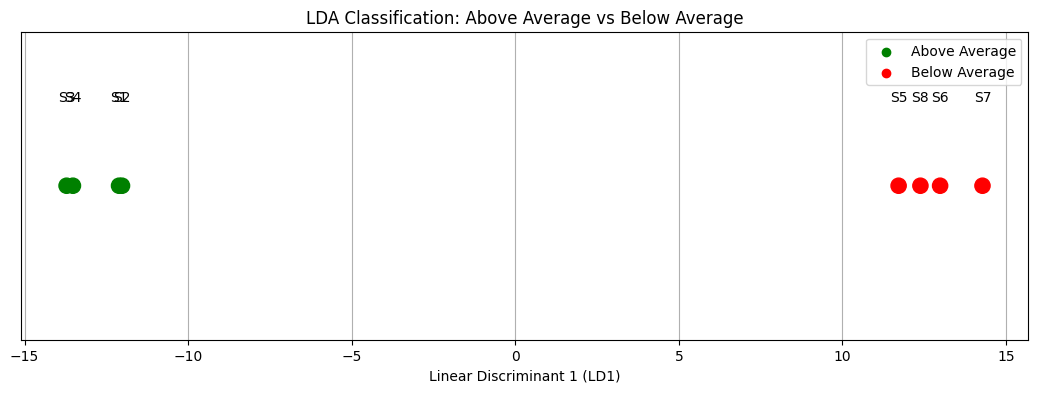

In [20]:
# ----------------------------------------------------
# Apply Linear Discriminant Analysis (LDA) to classify students into "Above Average" and "Below Average"
# ----------------------------------------------------

# Student Performance Dataset
data = pd.DataFrame({
    "Math":     [85, 80, 75, 90, 60, 55, 50, 45],
    "Science":  [90, 85, 80, 95, 58, 52, 48, 46],
    "English":  [78, 82, 70, 88, 60, 55, 50, 48],
    "Physics":  [92, 88, 85, 94, 62, 58, 52, 50],
    "Computer": [88, 84, 78, 92, 65, 60, 55, 52],
    "Category": [
        "Above Average",
        "Above Average",
        "Above Average",
        "Above Average",
        "Below Average",
        "Below Average",
        "Below Average",
        "Below Average"
    ]
})

print("Original Dataset")
print(data)

# -------------------------------
# Features
# -------------------------------

X = data[["Math", "Science", "English", "Physics", "Computer"]]

# Target Labels
y = data["Category"]

# -------------------------------
# Standardize Features
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Apply LDA
# -------------------------------

lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X_scaled, y)

# Create DataFrame
lda_df = pd.DataFrame({
    "LD1": X_lda.flatten(),
    "Category": y
})

print("\nDataset After LDA")
print(lda_df)

# -------------------------------
# Visualization
# -------------------------------

plt.figure(figsize=(13,4))

colors = [
    "green" if label == "Above Average"
    else "red"
    for label in y
]

plt.scatter(
    lda_df["LD1"],
    np.zeros(len(lda_df)),
    c=colors,
    s=120
)

# Student Labels
for i in range(len(lda_df)):
    plt.text(
        lda_df["LD1"][i],
        0.03,
        f"S{i+1}",
        ha="center"
    )

plt.yticks([])
plt.xlabel("Linear Discriminant 1 (LD1)")
plt.title("LDA Classification: Above Average vs Below Average")

# Legend
plt.scatter([], [], color="green", label="Above Average")
plt.scatter([], [], color="red", label="Below Average")
plt.legend(loc="upper right")

plt.grid(True)
plt.show()